# X-ray form factors and neutron scattering lengths

This example shows how to look up neutral-atom x-ray Cromer-Mann form factor
coefficients and neutron coherent scattering lengths from the bundled element
data, plot f(stol) curves across the periodic table, and use
`get_neutral_symbol` to bridge CIF ion labels into the neutral-atom lookups
required for structure-factor calculations later in Phase 7.

We work through four sections. First we look up two elements two different
ways, silicon by symbol and iron by atomic number. Then we plot f(stol) for
six elements spanning the periodic table from hydrogen to tungsten. Next we
tabulate the Q-independent neutron scattering lengths for the same set. We
finish with NaCl, loading the CIF, iterating its sites, and stripping the
ionic charge so the neutral-atom scattering functions apply.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from diffraction import (
    Crystal,
    SpaceGroup,
    get_element,
    get_neutral_symbol,
    neutron_scattering_length,
    xray_form_factor,
)

## Element lookup

`get_element` accepts either an element symbol or an atomic number and
returns a frozen `Element` dataclass with the Cromer-Mann coefficients and
the neutron coherent scattering length. We use silicon (Z = 14) for the
symbol lookup and iron (Z = 26) for the number lookup, showing that the
two dispatch paths are independent.

In [2]:
silicon = get_element("Si")
iron = get_element(26)

print(
    f"Symbol lookup:  Z = {silicon.z}, "
    f"symbol = {silicon.symbol}, "
    f"name = {silicon.name}"
)
print(f"Number lookup:  Z = {iron.z}, symbol = {iron.symbol}, name = {iron.name}")
print()
print(f"Silicon Cromer-Mann a: {silicon.cromer_mann_a}")
print(f"Silicon Cromer-Mann b: {silicon.cromer_mann_b}")
print(f"Silicon Cromer-Mann c: {silicon.cromer_mann_c:.4f}")
print(f"Silicon neutron b_coh: {silicon.neutron_b_coh:.4f} fm")

Symbol lookup:  Z = 14, symbol = Si, name = Silicon
Number lookup:  Z = 26, symbol = Fe, name = Iron

Silicon Cromer-Mann a: [6.2915 3.0353 1.9891 1.541 ]
Silicon Cromer-Mann b: [ 2.4386 32.3337  0.6785 81.6937]
Silicon Cromer-Mann c: 1.1407
Silicon neutron b_coh: 4.1491 fm


## X-ray form factor curves across the periodic table

The x-ray form factor f(stol) is the Fourier transform of the atomic
electron density, parametrised by four Gaussians plus a constant (Cromer
and Mann, Acta Cryst. A 24, 321). The argument stol = sin(theta) / lambda
has units of inverse Angstroms. At stol = 0 the integral reduces to the
total electron count Z, so every curve starts near its atomic number and
falls off as the electron cloud is resolved.

We plot f(stol) for six elements spanning the periodic table, from
hydrogen (Z = 1) through carbon, silicon, iron, and copper, to tungsten
(Z = 74).

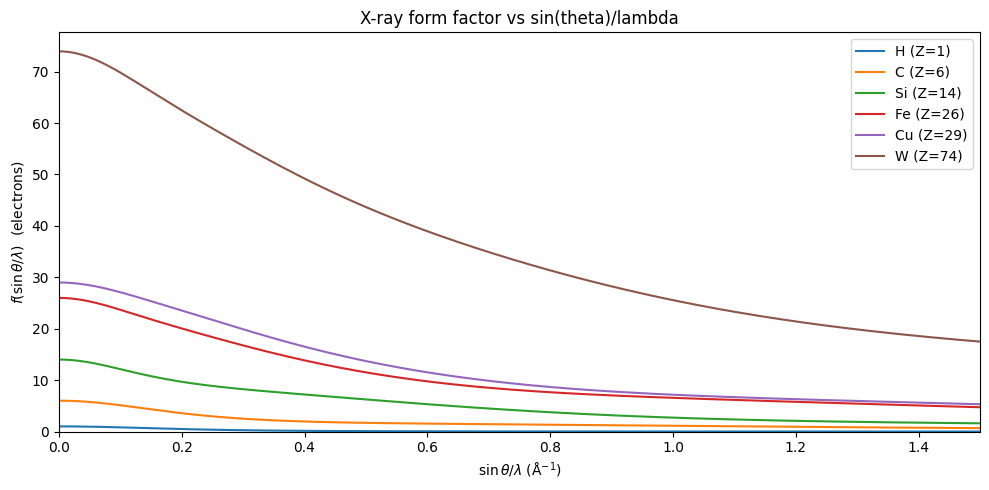

In [3]:
symbols = ["H", "C", "Si", "Fe", "Cu", "W"]
stol = np.linspace(0.0, 1.5, 200)  # inverse angstroms

fig, ax = plt.subplots(figsize=(10, 5))
for sym in symbols:
    elem = get_element(sym)
    f = xray_form_factor(sym, stol)
    ax.plot(stol, f, label=f"{sym} (Z={elem.z})")

ax.set_xlabel(r"$\sin\theta / \lambda$ ($\mathrm{\AA}^{-1}$)")
ax.set_ylabel(r"$f(\sin\theta / \lambda)$  (electrons)")
ax.set_xlim(0.0, 1.5)
ax.set_ylim(0.0, None)
ax.legend(loc="upper right")
ax.set_title("X-ray form factor vs sin(theta)/lambda")
fig.tight_layout()
plt.show()

## Neutron coherent scattering lengths

Thermal neutrons scatter from nuclei, so the coherent scattering length
b_coh is a scalar per isotope and does not fall off with Q. We print the
bundled values in femtometres for the same six elements we plotted above.

In [4]:
print(f"{'Symbol':>6}  {'Z':>3}  {'b_coh (fm)':>12}")
print("-" * 27)
for sym in symbols:
    elem = get_element(sym)
    print(f"{elem.symbol:>6}  {elem.z:>3}  {elem.neutron_b_coh:>12.4f}")

Symbol    Z    b_coh (fm)
---------------------------
     H    1       -3.7390
     C    6        6.6460
    Si   14        4.1491
    Fe   26        9.4500
    Cu   29        7.7180
     W   74        4.8600


## Real-crystal contrast on NaCl

CIF files label atomic sites with their ionic state, for example `Na1+`
and `Cl1-` for rock salt. The bundled form factors are for neutral atoms
only. `get_neutral_symbol` strips the charge and returns the element
symbol, letting us pass CIF sites into the neutral-atom lookup. This is
the integration point that downstream structure-factor helpers will call
explicitly.

In [5]:
nacl = Crystal.from_cif("nacl.cif")
sg_nacl = SpaceGroup("Fm-3m")
full_nacl = nacl.expand_sites(sg_nacl)

# One lookup per element. Iterate expanded sites, deduplicate by neutral symbol.
seen: list[str] = []
for site in full_nacl:
    neutral = get_neutral_symbol(site.ion)
    if neutral not in seen:
        seen.append(neutral)

stol_rep = 0.25  # inverse angstroms, representative mid-range value
print(f"NaCl scattering at stol = {stol_rep:.4f} (inverse angstroms)")
print()
print(f"{'CIF label':>10}  {'Neutral':>8}  {'f(stol)':>10}  {'b_coh (fm)':>12}")
print("-" * 46)
for neutral in seen:
    cif_label = next(s.ion for s in full_nacl if get_neutral_symbol(s.ion) == neutral)
    f_xray = xray_form_factor(neutral, stol_rep)
    b_coh = neutron_scattering_length(neutral)
    print(f"{cif_label:>10}  {neutral:>8}  {f_xray:>10.4f}  {b_coh:>12.4f}")

NaCl scattering at stol = 0.2500 (inverse angstroms)

 CIF label   Neutral     f(stol)    b_coh (fm)
----------------------------------------------
      Na1+        Na      7.6240        3.6300
      Cl1-        Cl     10.6352        9.5770


The next notebook in the series (`05_xray_vs_neutron`) builds on these
lookups to compute full structure factors and intensities, where the
contrast between x-ray and neutron scattering is resolved into peak
heights for individual reflections.